# Supervised Economic Valuation (LVQ Classification)

This notebook uses **Generalized Learning Vector Quantization (GLVQ)** via `sklvq`.
We discretize the client's continuous economic value into 3 Classes (Low, Medium, High) using K-Means clustering.
We extract Prototypes (Codebooks) to interpret the persona of High-Value buyers.

## 1. Setup & Data Load
Setup dataset and apply standard filtering rules.

In [1]:
# --- Fix for sklvq compatibility with scikit-learn >= 1.6 ---
from sklearn.base import BaseEstimator
import sklearn.utils.validation as val

# Ensure idempotency to prevent RecursionError when running the cell multiple times
if not hasattr(val, '_original_check_array'):
    val._original_check_array = val.check_array
    val._original_check_X_y = val.check_X_y

    def patched_check_array(*args, **kwargs):
        kwargs.setdefault('ensure_all_finite', kwargs.pop('force_all_finite', True))
        return val._original_check_array(*args, **kwargs)

    def patched_check_X_y(*args, **kwargs):
        kwargs.setdefault('ensure_all_finite', kwargs.pop('force_all_finite', True))
        return val._original_check_X_y(*args, **kwargs)

    val.check_array = patched_check_array
    val.check_X_y = patched_check_X_y

if not hasattr(BaseEstimator, '_patched_already'):
    def patched_validate_data(self, X="no_validation", y="no_validation", reset=True, validate_separately=False, **kwargs):
        kwargs.setdefault('ensure_all_finite', kwargs.pop('force_all_finite', True))
        if y is None or (isinstance(y, str) and y == "no_validation"):
            X_out = val.check_array(X, **kwargs)
            out = X_out
        else:
            X_out, y_out = val.check_X_y(X, y, **kwargs)
            out = X_out, y_out
        if reset:
            self.n_features_in_ = X_out.shape[1]
        return out

    BaseEstimator._validate_data = patched_validate_data
    BaseEstimator._patched_already = True
# ------------------------------------------------------------

import sys
import subprocess
from sklvq import GLVQ


import numpy as np
import pandas as pd
import pickle
import logging
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger(__name__)

# Load Data
df_raw = pd.read_excel(r"./Data/Dataset1_BankClients.xlsx")
df = df_raw.drop(columns=["ID"])

# Handle Missing Values
categorical_cols = ["Gender", "Job", "Area"]
numerical_cols = [c for c in df.columns if c not in categorical_cols]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Minor filter
mask_minors = (df["Age"] < 18) & (df["Job"].isin([2, 3, 4]))
df = df[~mask_minors].reset_index(drop=True)

# Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42)
labels = iso.fit_predict(df[numerical_cols])
df = df[labels == 1].reset_index(drop=True)

# Load Cluster Labels
with open(Path("results") / "weighted_results.pkl", "rb") as f:
    weighted_res = pickle.load(f)
df["Cluster"] = weighted_res["winner_lbls"]

## 2. K-Means Target Discretization
Instead of arbitrary chunks, we extract the 3 Natural centers of Economic Value distribution via K-Means.

In [2]:
# Phase 2: Target Discretization with K-Means
# Base features
# Fix 2: Feature Engineering Combinations
epsilon = 1e-5
df["Wealth_to_Debt"]  = np.clip(df["Wealth"] / (df["Debt"] + epsilon), -10, 100)
df["Saving_Rate"]     = np.clip(df["Saving"] / (df["Income"] + epsilon), -10, 100)
df["Digital_ESG"]     = df["Digital"] * df["ESG"]
df["Product_Breadth"] = (df["Investments"] / df["Investments"].max()) + (df["Saving"] / df["Saving"].max())

# Synthetic CLV Proxy Setup
df["AUM_Proxy"] = (df["Wealth"] + df["Investments"]) / 2.0
df["Debt_Margin"] = df["Debt"] * df["Income"]
df["Digital_Multiplier"] = 1.0 + (df["Digital"] * 0.2)
df["Churn_Risk"] = np.where((df["Age"] < 30) & (df["Job"] == 1), 0.3, 
                     np.where((df["Age"] > 70) & (df["Digital"] < df["Digital"].median()), 0.2, 0.05))

raw_clv = ( (df["Product_Breadth"] * 0.3) + (df["AUM_Proxy"] * 0.4) + (df["Debt_Margin"] * 0.3) ) * df["Digital_Multiplier"] * (1 - df["Churn_Risk"])
df["CLV_Proxy"] = (raw_clv - raw_clv.min()) / (raw_clv.max() - raw_clv.min())

# --- K-Means sul CLV_Proxy per trovare soglie naturali ---
km = KMeans(n_clusters=3, random_state=42, n_init=20)
km.fit(df[["CLV_Proxy"]].values)

# Rimappa i label in ordine crescente (0=Low, 1=Med, 2=High)
order = km.cluster_centers_.flatten().argsort()
remap = {old: new for new, old in enumerate(order)}
df["CustomerValue"] = pd.Series(km.labels_).map(remap)

print("Distribuzione CustomerValue post K-Means:")
print(df["CustomerValue"].value_counts().sort_index())
print("\nSoglie naturali K-Means:")
for i, c in enumerate(sorted(km.cluster_centers_.flatten())):
    print(f"  Centroide {i}: CLV_Proxy = {c:.4f}")

Distribuzione CustomerValue post K-Means:
CustomerValue
0    1713
1    1487
2    1750
Name: count, dtype: int64

Soglie naturali K-Means:
  Centroide 0: CLV_Proxy = 0.2438
  Centroide 1: CLV_Proxy = 0.5236
  Centroide 2: CLV_Proxy = 0.7641


## 3. Preprocessing Feature Injection
The nuanced ratios (Wealth-Debt, Saving-Ratio) feed standard scaler alongside the pure demographics.

In [3]:
# Phase 3: Preprocessing
# Fix 2: Updated feature mapping to capture nuanced Medium segments
# Fix 4: Hard cap demographic Age before standardization to prevent uninterpretable out-of-bounds prototype generation (e.g. 104yo)
df["Age"] = np.clip(df["Age"], 18, 85)

feat_cols = [
    "Age", "Job",
    "Wealth", "Income", "Saving", "Debt",    
    "Wealth_to_Debt",                         
    "Saving_Rate",                            
    "Digital_ESG",                            
    "Product_Breadth",                        
]

df_model = df[feat_cols].copy()
df_model = pd.get_dummies(df_model, columns=["Job"], drop_first=False)

scaler = StandardScaler()
num_feats = [c for c in df_model.columns if not c.startswith("Job_")]
df_model[num_feats] = scaler.fit_transform(df_model[num_feats])

X = df_model.values
y = df["CustomerValue"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
logger.info(f"Train base shape: {X_train.shape}")

2026-03-23 21:50:40,557 - Train base shape: (3960, 14)


## 4. Multi-Prototype Training
`prototype_n_per_class=[1, 2, 1]` forces the solver to assign 2 distinct vector profiles to define the more chaotic 'Medium' economic class.

GLVQ Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.94      0.84       343
           1       0.81      0.12      0.21       297
           2       0.66      0.97      0.79       350

    accuracy                           0.71       990
   macro avg       0.74      0.68      0.61       990
weighted avg       0.74      0.71      0.63       990



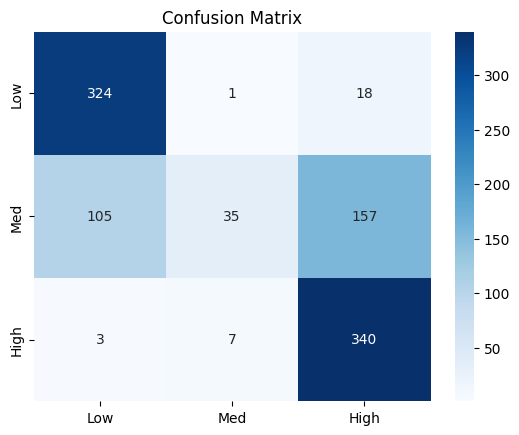

In [4]:
# Phase 4: Generalized Learning Vector Quantization (GLVQ)
# Fix 3: 3 Prototypes explicitly allocated to explore internal Medium class variance
glvq = GLVQ(
    distance_type="squared-euclidean",
    activation_type="sigmoid",
    activation_params={"beta": 2},
    solver_type="steepest-gradient-descent",
    solver_params={"max_runs": 150, "step_size": 0.05},
    prototype_n_per_class=np.array([1, 3, 1]),  # Low=1, Medium=3, High=1
    random_state=42,
)

glvq.fit(X_train, y_train)

y_pred = glvq.predict(X_test)
print("GLVQ Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Med", "High"], yticklabels=["Low", "Med", "High"])
plt.title("Confusion Matrix")
plt.show()

## 5. Inverse Prototype Extraction
Retrieving the learned vectors representing the class archetypes.

THE 5 LEARNED PROTOTYPE CODEBOOKS:


,Prototype_Name,Assigned_Class,Age,Wealth,Income,Saving,Debt,Wealth_to_Debt,Saving_Rate,Digital_ESG,Product_Breadth,Job_1,Job_2,Job_3,Job_4,Job_5
0,Low A,Low,72.465,0.443,0.457,0.485,0.289,3.435,1.212,0.223,0.409,0.153,0.371,-0.007,0.034,0.449
1,Medium A,Medium,60.445,0.521,0.549,0.290,0.151,-1.989,0.391,-0.065,2.370,0.974,-0.103,0.238,-0.017,-0.091
2,Medium B,Medium,47.520,0.778,0.636,0.615,0.407,-8.300,1.191,0.415,0.768,-0.194,2.656,1.026,0.049,-2.542
3,Medium C,Medium,113.019,0.516,0.478,0.463,0.481,-1.463,0.699,-0.033,2.062,0.054,1.654,0.050,-0.120,-0.637
4,High A,High,47.025,0.715,0.709,0.573,0.578,1.166,0.863,0.450,2.117,0.007,0.896,0.060,0.017,0.019


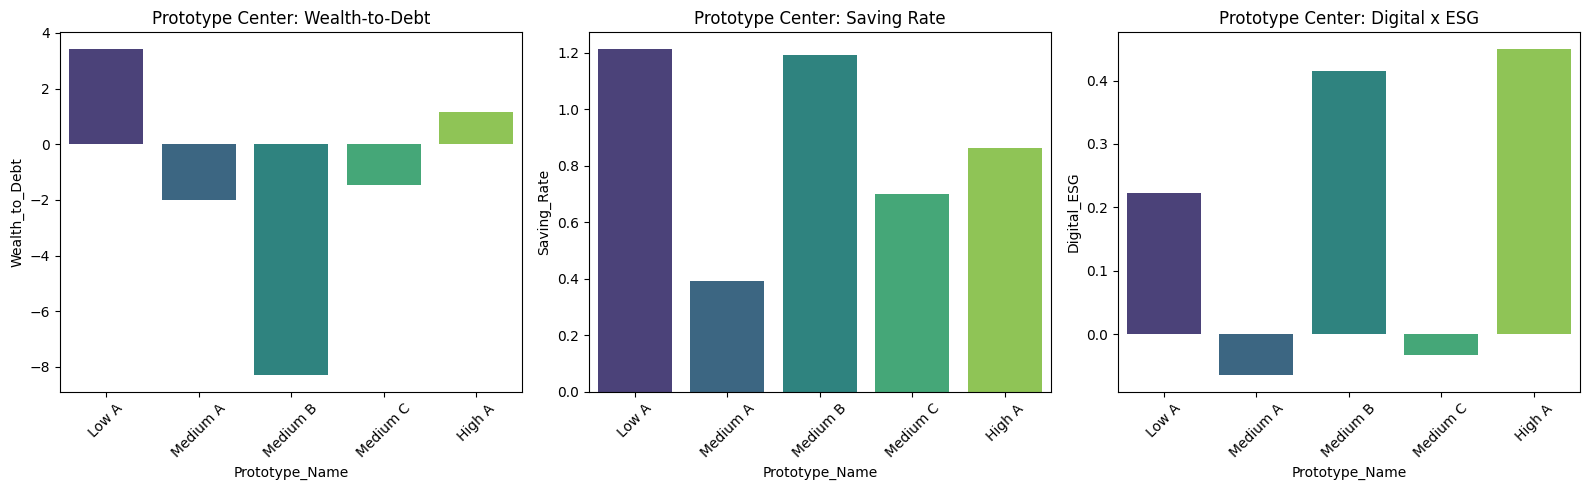

In [5]:
# Phase 5: Codebook Prototypes Inverse Scaling
prototypes = glvq.prototypes_
labels = glvq.prototypes_labels_

proto_df = pd.DataFrame(prototypes, columns=df_model.columns)
proto_df[num_feats] = scaler.inverse_transform(proto_df[num_feats])
proto_df.insert(0, "Assigned_Class", labels)
proto_df["Assigned_Class"] = proto_df["Assigned_Class"].map({0: "Low", 1: "Medium", 2: "High"})

# Distinguish multiple prototypes in the same class (Medium A, Medium B...)
counts = {}
names = []
for c in proto_df["Assigned_Class"]:
    counts[c] = counts.get(c, 0) + 1
    names.append(f"{c} {chr(64 + counts[c])}")
proto_df.insert(0, "Prototype_Name", names)

print(f"THE {len(prototypes)} LEARNED PROTOTYPE CODEBOOKS:")
display(proto_df.round(3))

# Compare Key Features across all Prototypes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=proto_df, x="Prototype_Name", y="Wealth_to_Debt", ax=axes[0], palette="viridis", hue="Prototype_Name", legend=False)
axes[0].set_title("Prototype Center: Wealth-to-Debt")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=proto_df, x="Prototype_Name", y="Saving_Rate", ax=axes[1], palette="viridis", hue="Prototype_Name", legend=False)
axes[1].set_title("Prototype Center: Saving Rate")
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=proto_df, x="Prototype_Name", y="Digital_ESG", ax=axes[2], palette="viridis", hue="Prototype_Name", legend=False)
axes[2].set_title("Prototype Center: Digital x ESG")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Business Mapping
Crossing the trained Classification back across the Unsupervised Clustering pipeline.

Cluster Distribution across the 3 Economic Classes (combining all 5 Prototypes):


,Low Val %,Med Val %,High Val %
Cluster,,,
6,28.0,4.9,67.1
5,29.2,4.8,66.0
8,35.5,3.5,61.0
2,31.3,8.3,60.4
0,35.2,5.5,59.4
9,36.2,7.4,56.3
4,59.0,2.8,38.2
1,67.1,7.7,25.2
7,86.1,0.3,13.6


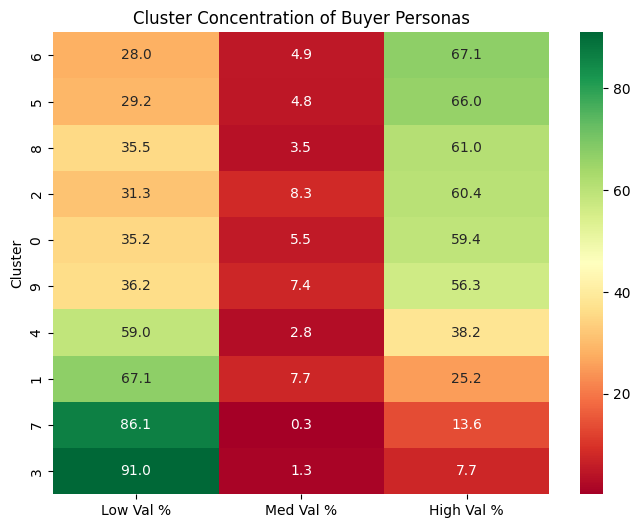

In [6]:
# Phase 6: Unsupervised Cluster Integration
# Full dataset prediction (Maps the dataset through the 5 prototypes to exactly 3 Economic Classes)
df["Predicted_Econ_Class"] = glvq.predict(X)

cross_tab = pd.crosstab(df["Cluster"], df["Predicted_Econ_Class"], normalize="index") * 100
cross_tab.columns = ["Low Val %", "Med Val %", "High Val %"]
ranked_clusters = cross_tab.sort_values(by="High Val %", ascending=False)

print("Cluster Distribution across the 3 Economic Classes (combining all 5 Prototypes):")
display(ranked_clusters.round(1))

plt.figure(figsize=(8, 6))
sns.heatmap(ranked_clusters, annot=True, fmt=".1f", cmap="RdYlGn")
plt.title("Cluster Concentration of Buyer Personas")
plt.show()